# Домашнее задание к семинару 12 (HW12)
Тема: временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.

## Импорт библиотек

In [79]:
# Базовые библиотеки для генерации данных, анализа и обучения простых моделей.
import math
import random
from dataclasses import dataclass
import os
import csv
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# PyTorch для построения и обучения нейросетей
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Делаем графики и табличный вывод чуть удобнее для демонстрации в ноутбуке.
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [80]:
# Установка seed для воспроизводимости результатов
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определяем устройство: используем GPU если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Данные и первичный анализ

In [81]:
df = pd.read_csv("https://raw.githubusercontent.com/mirea-aie-2025/aie-course-meta/refs/heads/main/seminars/S12/S12-hw-dataset.csv")
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [82]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Число наблюдений: {len(df)}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print("Число пропусков по колонкам:", df.isnull().sum(), sep="\n")

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Число пропусков по колонкам:
date      0
target    0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


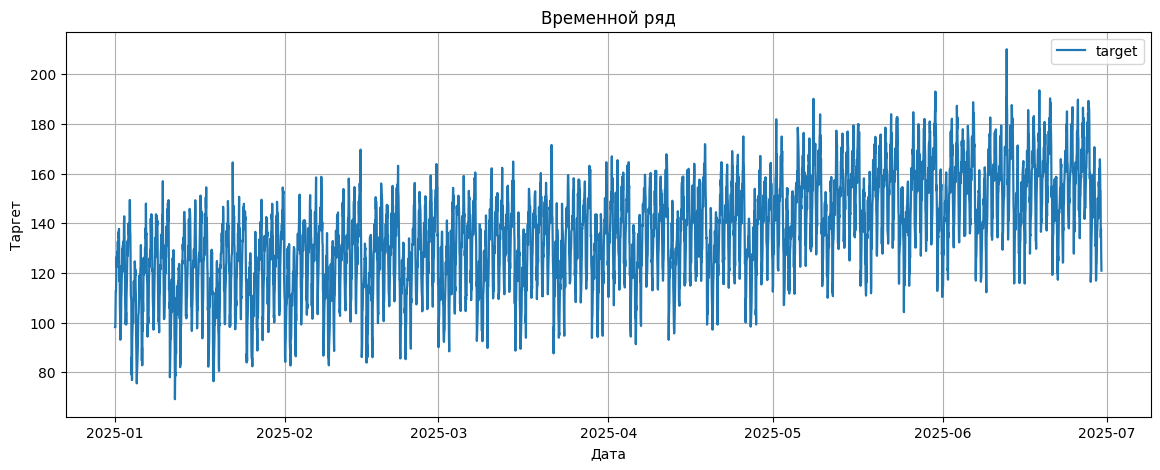

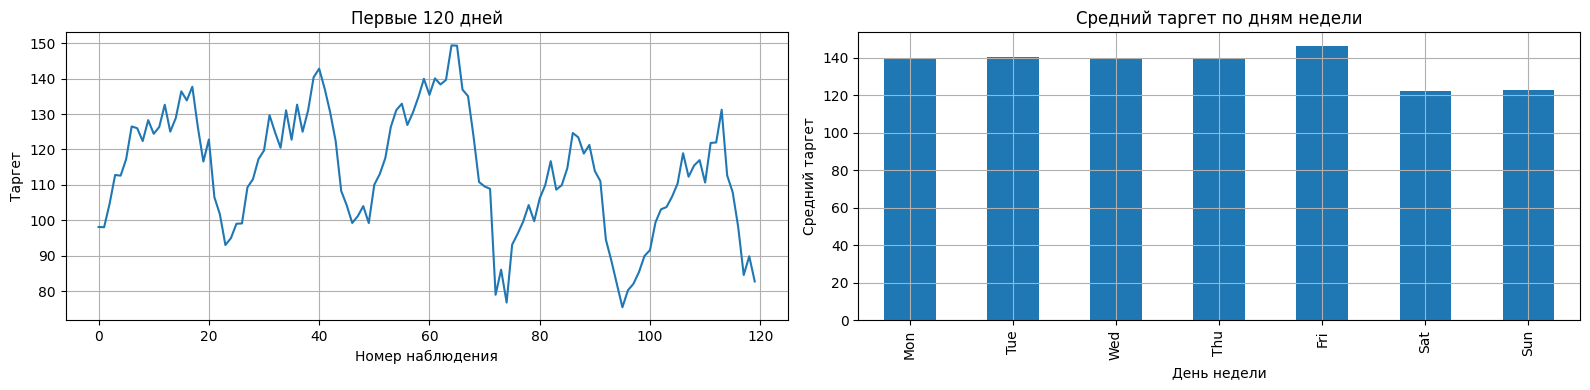

In [83]:
# Сначала смотрим сводную статистику, затем визуально проверяем форму ряда и сезонность.
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Временной ряд")
ax.set_xlabel("Дата")
ax.set_ylabel("Таргет")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Крупным планом видно локальную динамику и уровень шума в начале ряда.
df["target"].iloc[:120].plot(ax=axes[0], title="Первые 120 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("Таргет")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средний таргет по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средний таргет")

plt.tight_layout()
plt.show()

Описание временного ряда:
* есть долгосрочный рост,
* есть недельная сезонность (разные дни недели ведут себя по-разному),
* есть медленная годовая сезонность,
* есть случайный шум.

## Корректный temporal split

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


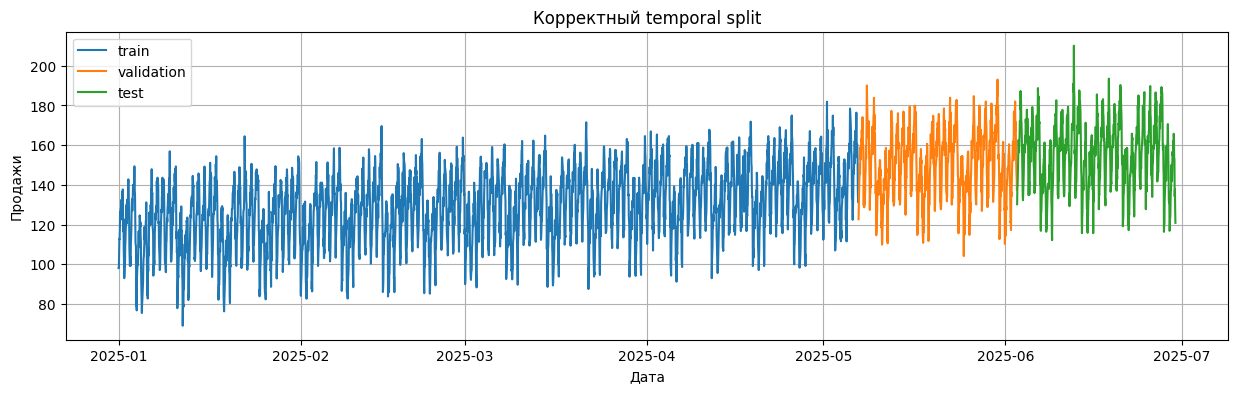

In [84]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.savefig("./artifacts/figures/series_split.png", dpi=300, bbox_inches="tight")
plt.show()

Почему random split некорректен для временных рядов:

Временные ряды обладают временной зависимостью: каждое значение зависит от предыдущих.
Если использовать random split (перемешивание данных):
- модель может обучаться на будущих значениях
- и тестироваться на прошлых

Это приводит к утечке информации (data leakage) и нереалистично хорошим результатам.
Поэтому используется **temporal split**:
train → validation → test строго по времени.

## Признаки для baseline-моделей

In [85]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    # for lag in [1, 2, 3, 7, 14, 28]:
    #     out[f"lag_{lag}"] = out[target_col].shift(lag)
    out["lag_1"] = out[target_col].shift(1)
    out["lag_2"] = out[target_col].shift(2)
    out["lag_3"] = out[target_col].shift(3)
    out["lag_7"] = out[target_col].shift(7)
    out["lag_14"] = out[target_col].shift(14)
    out["lag_28"] = out[target_col].shift(28)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_28"] = out[target_col].shift(1).rolling(window=28).mean()
    out["rolling_std_28"] = out[target_col].shift(1).rolling(window=28).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_28,rolling_std_28
0,2025-01-02 04:00:00,111.64,3,1,109.33,99.14,99.05,106.54,128.87,98.14,100.545714,5.856307,116.487143,13.778753
1,2025-01-02 05:00:00,117.30,3,1,111.64,109.33,99.14,101.72,136.40,98.07,101.274286,6.942790,116.969286,13.342257
2,2025-01-02 06:00:00,119.72,3,1,117.30,111.64,109.33,93.04,133.85,104.70,103.500000,9.230043,117.656071,12.818023
3,2025-01-02 07:00:00,129.68,3,1,119.72,117.30,111.64,95.00,137.71,112.81,107.311429,9.688052,118.192500,12.567579
4,2025-01-02 08:00:00,124.85,3,1,129.68,119.72,117.30,99.05,126.32,112.62,112.265714,11.106433,118.795000,12.703625


In [86]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek", "month",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_28", "rolling_std_28",
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train_base = train_feat[feature_cols]
y_train_base = train_feat[target_col]

X_val_base = val_feat[feature_cols]
y_val_base = val_feat[target_col]

X_test_base = test_feat[feature_cols]
y_test_base = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train_base.shape, "| y_train:", y_train_base.shape)
print("X_val:  ", X_val_base.shape, "| y_val:  ", y_val_base.shape)
print("X_test: ", X_test_base.shape, "| y_test: ", y_test_base.shape)

Размерности:
X_train: (3004, 12) | y_train: (3004,)
X_val:   (644, 12) | y_val:   (644,)
X_test:  (644, 12) | y_test:  (644,)


## Оконное представление для GRU

In [87]:
# 1. Нормализация данных ТОЛЬКО по train набору (чтобы не было утечки информации)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

# переменная для inverse scaling'а
scaler_target = scaler

window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -0.8963408


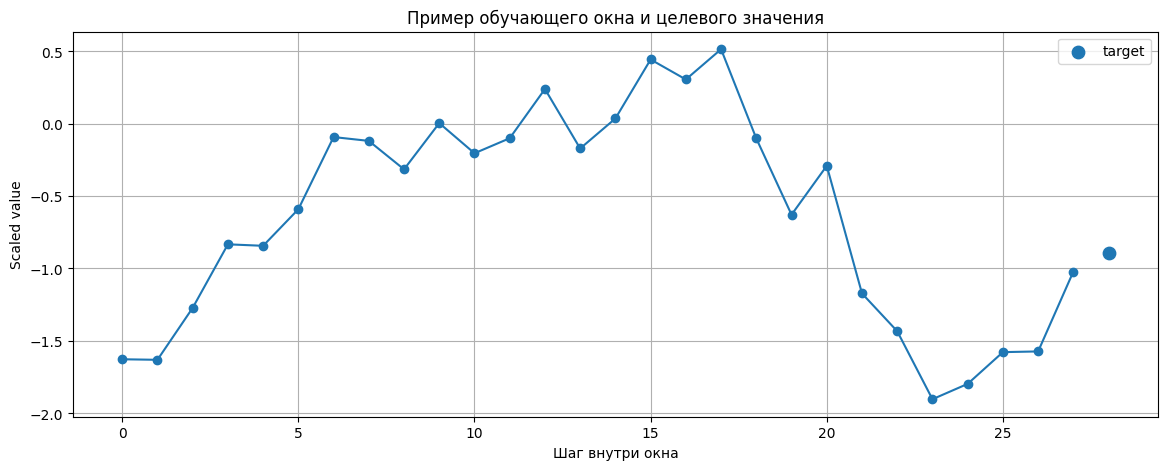

In [88]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [89]:
# Определяем PyTorch Dataset для обработки последовательностей
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)   # train не перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


## Базовые функции обучения и оценки

In [90]:
RUNS_PATH = './artifacts/runs.csv'

def log_run(
    experiment_id,
    task,
    dataset,
    seed,
    split_summary,
    window_size = None,
    horizon = None,
    features_summary = None,
    scaler = None,
    model_summary = None,
    optimizer = None,
    lr = None,
    epochs_trained = None,
    best_val_mae = None,
    best_val_rmse = None,
    best_val_mape = None,
    test_mae = None,
    test_rmse = None,
    test_mape = None,
    notes = None
):

    row = {
        "experiment_id": experiment_id,
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "split_summary": split_summary,
        "window_size": window_size,
        "horizon": horizon,
        "features_summary": features_summary,
        "scaler": scaler,
        "model_summary": model_summary,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": best_val_mae,
        "best_val_rmse": best_val_rmse,
        "best_val_mape": best_val_mape,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape,
        "notes": notes
    }

    file_exists = os.path.exists(RUNS_PATH)

    with open(RUNS_PATH, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(row)

In [91]:
def update_run_with_test_metrics(
    experiment_id: str,
    test_mae: float,
    test_rmse: float,
    test_mape: float,
    runs_path: str = "./artifacts/runs.csv"
):
    """
    Обновляет существующую запись эксперимента, добавляя тестовые метрики.
    """
    # Проверяем, существует ли файл
    if not os.path.exists(runs_path):
        raise FileNotFoundError(f"Файл {runs_path} не найден")

    # Читаем существующий CSV
    df = pd.read_csv(runs_path)

    # Проверяем, существует ли эксперимент
    if experiment_id not in df['experiment_id'].values:
        raise ValueError(f"Эксперимент {experiment_id} не найден в runs.csv")

    # Обновляем тестовые метрики для указанного эксперимента
    mask = df['experiment_id'] == experiment_id
    df.loc[mask, 'test_mae'] = test_mae
    df.loc[mask, 'test_rmse'] = test_rmse
    df.loc[mask, 'test_mape'] = test_mape

    # Сохраняем обновленный файл
    df.to_csv(runs_path, index=False)
    print(f"Эксперимент {experiment_id} обновлен с тестовыми метриками:")
    print(f"   test_mae: {test_mae:.4f}")
    print(f"   test_rmse: {test_rmse:.4f}")
    print(f"   test_mape: {test_mape:.2f}%")

In [92]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [93]:
# Небольшие вспомогательные функции для единообразной оценки всех моделей.
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

In [94]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def naive_baseline_from_windows(X: np.ndarray) -> np.ndarray:
    """
    Простой baseline: для каждого окна предсказываем последнее значение.
    Часто это хороший опорный результат для временных рядов.
    """
    return X[:, -1, 0]

## Эксперименты

### B1 (naive-last): наивный baseline, где прогноз равен последнему известному значению.

In [95]:
# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()

baseline_results_val = pd.concat([
    evaluate_regression(y_val_base, val_pred_naive, "Naive (lag_1)"),
], ignore_index=True)

print("Validation:")
display(baseline_results_val)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.441118,8.207078,4.39362


In [96]:
log_run(
    experiment_id="B1",
    task="forecasting",
    dataset="S12-hw-dataset",
    seed=42,
    horizon=1,
    split_summary="temporal split",
    features_summary=feature_cols,
    model_summary="Naive baseline",
    best_val_mae=baseline_results_val.loc[baseline_results_val['model'] == 'Naive (lag_1)', 'MAE'].values[0],
    best_val_rmse=baseline_results_val.loc[baseline_results_val['model'] == 'Naive (lag_1)', 'RMSE'].values[0],
    best_val_mape=baseline_results_val.loc[baseline_results_val['model'] == 'Naive (lag_1)', 'MAPE_%'].values[0]
)

### B2 (moving-average): baseline на основе скользящего среднего по окну разумного размера.

In [97]:
# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()

baseline_results_val = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val_base, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

print("Validation:")
display(baseline_results_val)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.441118,8.207078,4.393620
1,MovingAverage(7),12.697560,15.226533,8.812577


In [98]:
log_run(
    experiment_id="B2",
    task="forecasting",
    dataset="S12-hw-dataset",
    seed=42,
    horizon=1,
    split_summary="temporal split",
    features_summary=feature_cols,
    model_summary="Moving average baseline",
    best_val_mae=baseline_results_val.loc[baseline_results_val['model'] == 'MovingAverage(7)', 'MAE'].values[0],
    best_val_rmse=baseline_results_val.loc[baseline_results_val['model'] == 'MovingAverage(7)', 'RMSE'].values[0],
    best_val_mape=baseline_results_val.loc[baseline_results_val['model'] == 'MovingAverage(7)', 'MAPE_%'].values[0],
    window_size=7
)

### B3 (ridge-lag-features): Ridge (или LinearRegression) на лаговых, rolling- и календарных признаках.

In [99]:
# Ridge чувствителен к масштабу признаков, поэтому его обучаем на стандартизованных данных.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_base)
X_val_scaled = scaler.transform(X_val_base)
X_test_scaled = scaler.transform(X_test_base)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_base)

val_pred_ridge = ridge.predict(X_val_scaled)

# Сравниваем модели на validation и test в единой таблице метрик.
val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val_base, val_pred_ridge, "Ridge")
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)

Validation:


,model,MAE,RMSE,MAPE_%
0,Ridge,5.110120,6.616048,3.432720
1,Naive (lag_1),6.441118,8.207078,4.393620
2,MovingAverage(7),12.697560,15.226533,8.812577


In [100]:
log_run(
    experiment_id="B3",
    task="forecasting",
    dataset="S12-hw-dataset",
    seed=42,
    horizon=1,
    split_summary="temporal split",
    features_summary=feature_cols,
    model_summary=ridge.__class__.__name__,
    scaler=scaler,
    best_val_mae=val_results.loc[val_results['model'] == 'Ridge', 'MAE'].values[0],
    best_val_rmse=val_results.loc[val_results['model'] == 'Ridge', 'RMSE'].values[0],
    best_val_mape=val_results.loc[val_results['model'] == 'Ridge', 'MAPE_%'].values[0],
)

### R1 (gru-forecast): GRU на оконном представлении ряда.

In [101]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [102]:
# Обучаем GRU с такими же параметрами как LSTM
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.7695 | val_loss=0.6465
Epoch 02 | train_loss=0.4325 | val_loss=0.3439
Epoch 03 | train_loss=0.2172 | val_loss=0.1883
Epoch 04 | train_loss=0.1698 | val_loss=0.1741
Epoch 05 | train_loss=0.1597 | val_loss=0.1704
Epoch 06 | train_loss=0.1556 | val_loss=0.1707
Epoch 07 | train_loss=0.1533 | val_loss=0.1720
Epoch 08 | train_loss=0.1517 | val_loss=0.1734
Epoch 09 | train_loss=0.1505 | val_loss=0.1745
Epoch 10 | train_loss=0.1494 | val_loss=0.1754
Epoch 11 | train_loss=0.1483 | val_loss=0.1759
Epoch 12 | train_loss=0.1470 | val_loss=0.1762
Epoch 13 | train_loss=0.1454 | val_loss=0.1763
Epoch 14 | train_loss=0.1435 | val_loss=0.1761
Epoch 15 | train_loss=0.1408 | val_loss=0.1758
Epoch 16 | train_loss=0.1360 | val_loss=0.1744
Epoch 17 | train_loss=0.1265 | val_loss=0.1608
Epoch 18 | train_loss=0.1147 | val_loss=0.1653
Epoch 19 | train_loss=0.1090 | val_loss=0.1697
Epoch 20 | train_loss=0.1067 | val_loss=0.1689
Epoch 21 | train_loss=0.1051 | val_loss=0

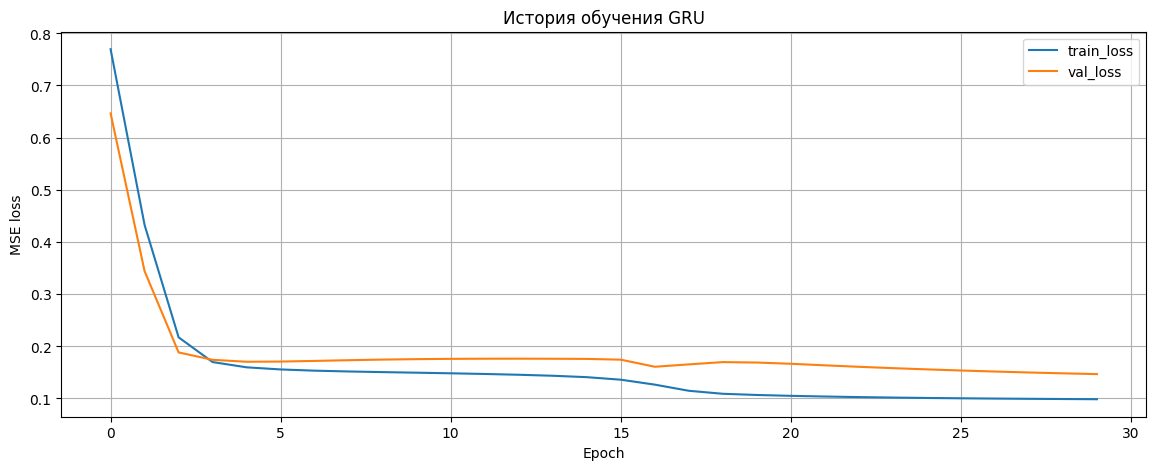

In [103]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig("./artifacts/figures/gru_learning_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [104]:
# Получаем предсказания на validation
gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)

# Восстанавливаем исходный масштаб
val_true = inverse_scale(gru_val_true_scaled, scaler_target)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler_target)

val_results = pd.concat([
    val_results,
    evaluate_regression(val_true, gru_val_pred, "GRU")
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

val_results

,model,MAE,RMSE,MAPE_%
0,Ridge,5.110120,6.616048,3.432720
1,GRU,5.535867,7.116367,3.712530
2,Naive (lag_1),6.441118,8.207078,4.393620
3,MovingAverage(7),12.697560,15.226533,8.812577


In [105]:
log_run(
    experiment_id="R1",
    task="forecasting",
    dataset="S12-hw-dataset",
    seed=42,
    horizon=1,
    features_summary=f"lagged target sequence: y(t-{window_size}) ... y(t-1)",
    split_summary="X_train: (2996, 28, 1) y_train: (2996,) X_val  : (620, 28, 1) y_val  : (620,) X_test : (620, 28, 1) y_test : (620,)",
    model_summary=gru_model.__class__.__name__,
    scaler=scaler_target,
    optimizer = "Adam",
    lr = 5e-4,
    window_size=window_size,
    epochs_trained = len(gru_history['train_loss']),
    best_val_mae=val_results.loc[val_results['model'] == 'GRU', 'MAE'].values[0],
    best_val_rmse=val_results.loc[val_results['model'] == 'GRU', 'RMSE'].values[0],
    best_val_mape=val_results.loc[val_results['model'] == 'GRU', 'MAPE_%'].values[0],
)

In [106]:
torch.save(gru_model.state_dict(), './artifacts/best_gru.pt')
print("Модель сохранена как best_gru.pt")

Модель сохранена как best_gru.pt


In [107]:
gru_config = {
    "experiment_id": "R1",
    "model_name": "GRUForecaster",
    "task": "forecasting",
    "dataset": "S12-hw-dataset",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.0,
    "batch_first": True,
    "window_size": window_size,
    "input_sequence_length": 28,
    "target_size": 1,
    "scaler": scaler_target.__class__.__name__,
    "seed": 42,
    "optimizer": "Adam",
    "learning_rate": 5e-4,
    "epochs_trained": len(gru_history['train_loss']),
    "batch_size": train_loader.batch_size if 'train_loader' in dir() else None,
    "loss_function": "MSE",
    "device": str(device)

}

# Сохраняем конфигурацию в JSON файл
with open('./artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=4, ensure_ascii=False)

### Выбор лучшей модели

In [108]:
best_model = val_results.loc[val_results['MAE'].idxmin()]
print(f"Лучшая модель: {best_model['model']} c наименьшей MAE = {best_model['MAE']}")

Лучшая модель: Ridge c наименьшей MAE = 5.110119825055506


Лучшей моделью выбрана модель эксперимента B3: Ridge, c наименьшей MAE = 5.110119825055506

In [109]:
test_pred_ridge = ridge.predict(X_test_scaled)
test_results = evaluate_regression(y_test_base, test_pred_ridge, "Ridge")

In [110]:
update_run_with_test_metrics('B3', test_results["MAE"][0], test_results["RMSE"][0], test_results["MAPE_%"][0])

Эксперимент B3 обновлен с тестовыми метриками:
   test_mae: 5.0978
   test_rmse: 6.5559
   test_mape: 3.32%


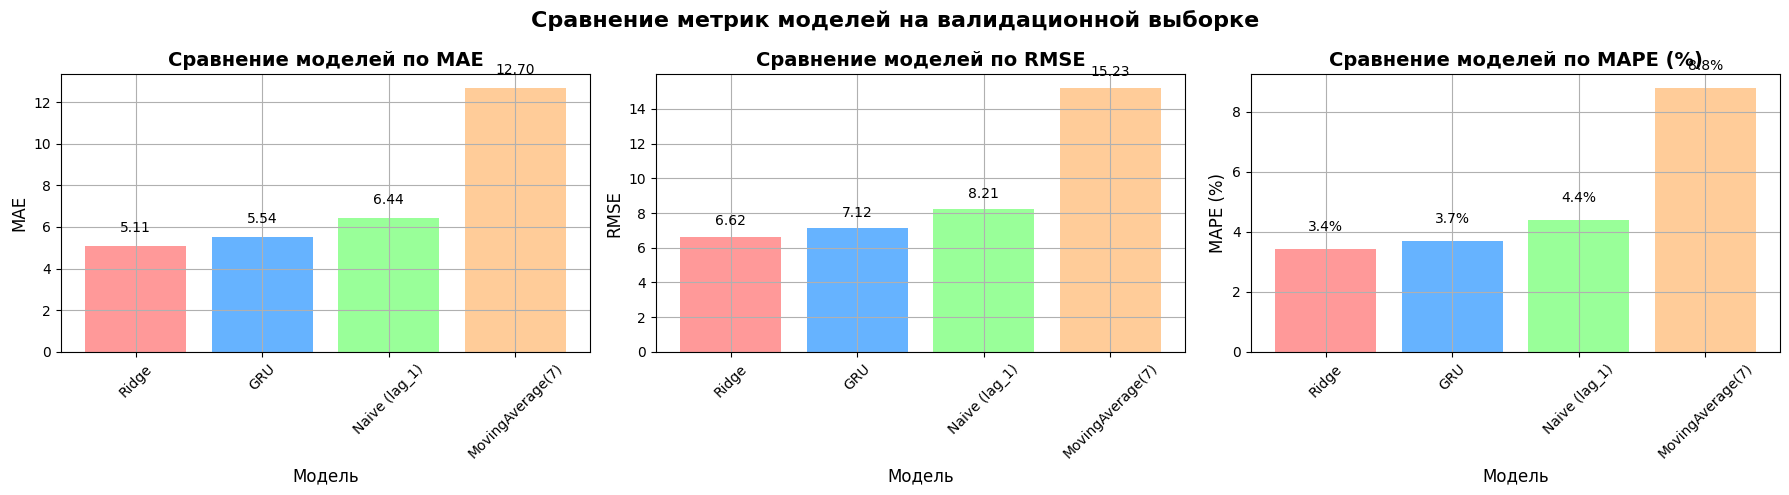

In [111]:
### Визуализация результатов

# 1. Сравнение baseline-моделей по метрикам на валидации
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
models = val_results['model'].values
mae_values = val_results['MAE'].values
bars1 = axes[0].bar(models, mae_values, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
axes[0].set_title('Сравнение моделей по MAE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MAE', fontsize=12)
axes[0].set_xlabel('Модель', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Добавляем значения на столбцы
for bar, val in zip(bars1, mae_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# RMSE
rmse_values = val_results['RMSE'].values
bars2 = axes[1].bar(models, rmse_values, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
axes[1].set_title('Сравнение моделей по RMSE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_xlabel('Модель', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

for bar, val in zip(bars2, rmse_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# MAPE
mape_values = val_results['MAPE_%'].values
bars3 = axes[2].bar(models, mape_values, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
axes[2].set_title('Сравнение моделей по MAPE (%)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('MAPE (%)', fontsize=12)
axes[2].set_xlabel('Модель', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

for bar, val in zip(bars3, mape_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Сравнение метрик моделей на валидационной выборке', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./artifacts/figures/baselines_compare.png', dpi=300, bbox_inches='tight')
plt.show()

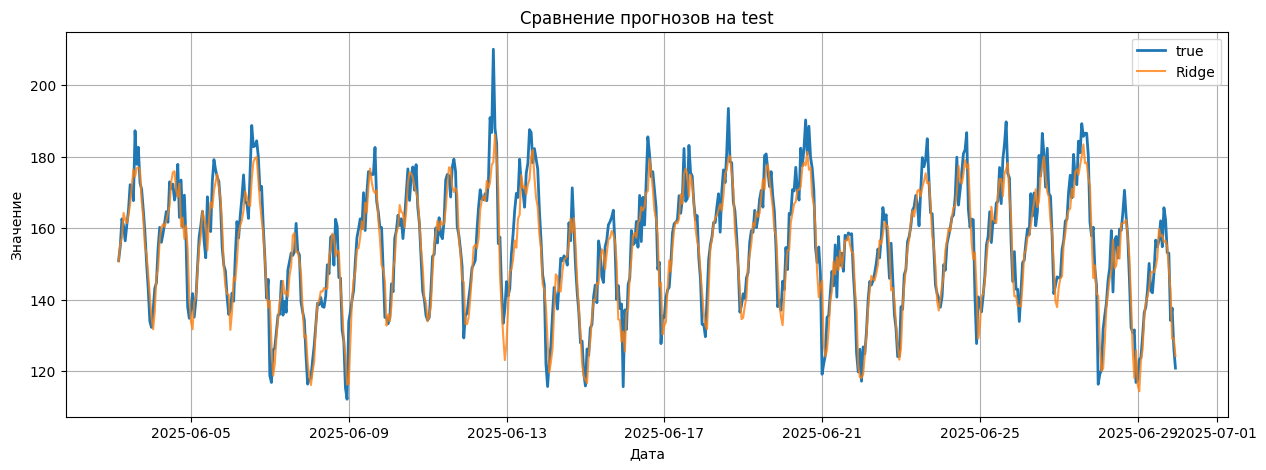

In [112]:
test_dates = test_feat['date'].values
test_actual = y_test_base.values
test_predicted = test_pred_ridge
# Объединяем даты и предсказания в одной таблице
plot_df = pd.DataFrame(
    {
        "date": test_dates,
        "true": test_actual,
        "Ridge": test_predicted,
    }
)

# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["Ridge"], label="Ridge", alpha=0.8)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig('./artifacts/figures/best_forecast_test.png', dpi=300, bbox_inches='tight')

plt.show()